---
## 1. Carga del archivo CSV (2%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_csv('clave_I_correlacion.csv')

print('Archivo cargado exitosamente.')
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

Archivo cargado exitosamente.
Dimensiones del dataset: 261 filas x 10 columnas


---
## 2. Identificación de variables numéricas del dataset (2%)

In [2]:
# Primeras filas
print('=== Primeras 10 filas ===')
display(df.head(10))

# Información general
print('\n=== Información general ===')
df.info()

# Variables numéricas
vars_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'\n=== Variables numéricas ({len(vars_numericas)}) ===')
for v in vars_numericas:
    print(f'  - {v}')

# Estadísticas descriptivas
print('\n=== Estadísticas descriptivas ===')
display(df[vars_numericas].describe().round(2))

=== Primeras 10 filas ===


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,I-C0001,18,1208,8,70.27,6.38,4,5,33.92,442.88
1,I-C0002,38,1221,7,77.75,7.44,2,6,22.83,543.68
2,I-C0003,45,1385,8,84.56,6.56,3,6,29.00,641.28
3,I-C0004,48,1044,4,71.45,4.79,4,4,29.42,262.21
4,I-C0005,31,808,5,51.72,7.92,1,4,19.00,321.18
5,I-C0006,34,1290,5,65.50,9.04,1,6,14.28,371.72
6,I-C0007,56,1557,10,97.16,8.17,0,6,19.90,854.46
7,I-C0008,52,1103,7,80.98,8.41,2,6,19.47,566.31
8,I-C0009,38,979,9,52.78,9.69,0,7,20.95,506.77
9,I-C0010,41,947,5,77.63,4.00,7,6,40.97,402.64



=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          261 non-null    object 
 1   edad                261 non-null    int64  
 2   ingresos_mensuales  261 non-null    int64  
 3   frecuencia_compra   261 non-null    int64  
 4   ticket_promedio     260 non-null    float64
 5   satisfaccion        260 non-null    float64
 6   reclamos            261 non-null    int64  
 7   uso_app             261 non-null    int64  
 8   tiempo_respuesta    260 non-null    float64
 9   consumo_total       261 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 20.5+ KB

=== Variables numéricas (9) ===
  - edad
  - ingresos_mensuales
  - frecuencia_compra
  - ticket_promedio
  - satisfaccion
  - reclamos
  - uso_app
  - tiempo_respuesta
  - consumo_total

=== Estadísticas descripti

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,261.00,261.00,261.00,260.00,260.00,261.00,261.00,260.00,261.00
mean,41.58,1306.67,8.79,75.44,7.62,1.54,6.30,21.16,636.67
std,9.58,249.94,3.43,15.11,1.27,1.56,1.88,6.13,248.72
min,18.00,616.00,3.00,36.07,2.50,0.00,1.00,8.26,163.82
25%,35.00,1145.00,7.00,65.68,6.92,0.00,5.00,16.63,505.26
50%,42.00,1301.00,8.00,77.03,7.76,1.00,6.00,20.70,592.59
75%,48.00,1491.00,10.00,84.96,8.54,2.00,8.00,25.30,729.65
max,68.00,1987.00,35.00,120.32,10.00,9.00,10.00,40.97,2317.66


**Interpretación:** El dataset contiene **9 variables numéricas** relevantes para el análisis de correlación:
- `edad`: edad del cliente (18 a 68 años, promedio 41).
- `ingresos_mensuales`: ingresos en moneda local (616 a 1987, promedio 1306).
- `frecuencia_compra`: número de compras realizadas.
- `ticket_promedio`: valor promedio por compra.
- `satisfaccion`: nivel de satisfacción del cliente.
- `reclamos`: número de reclamos realizados.
- `uso_app`: nivel de uso de la aplicación móvil.
- `tiempo_respuesta`: tiempo de respuesta del servicio.
- `consumo_total`: consumo total acumulado del cliente.

La variable `cliente_id` es un identificador de texto y se excluye del análisis de correlación.

---
## 3. Revisión de datos nulos, valores atípicos y consistencia general (3%)

=== Valores nulos por columna ===
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64
Total de valores nulos: 3

Filas duplicadas: 1


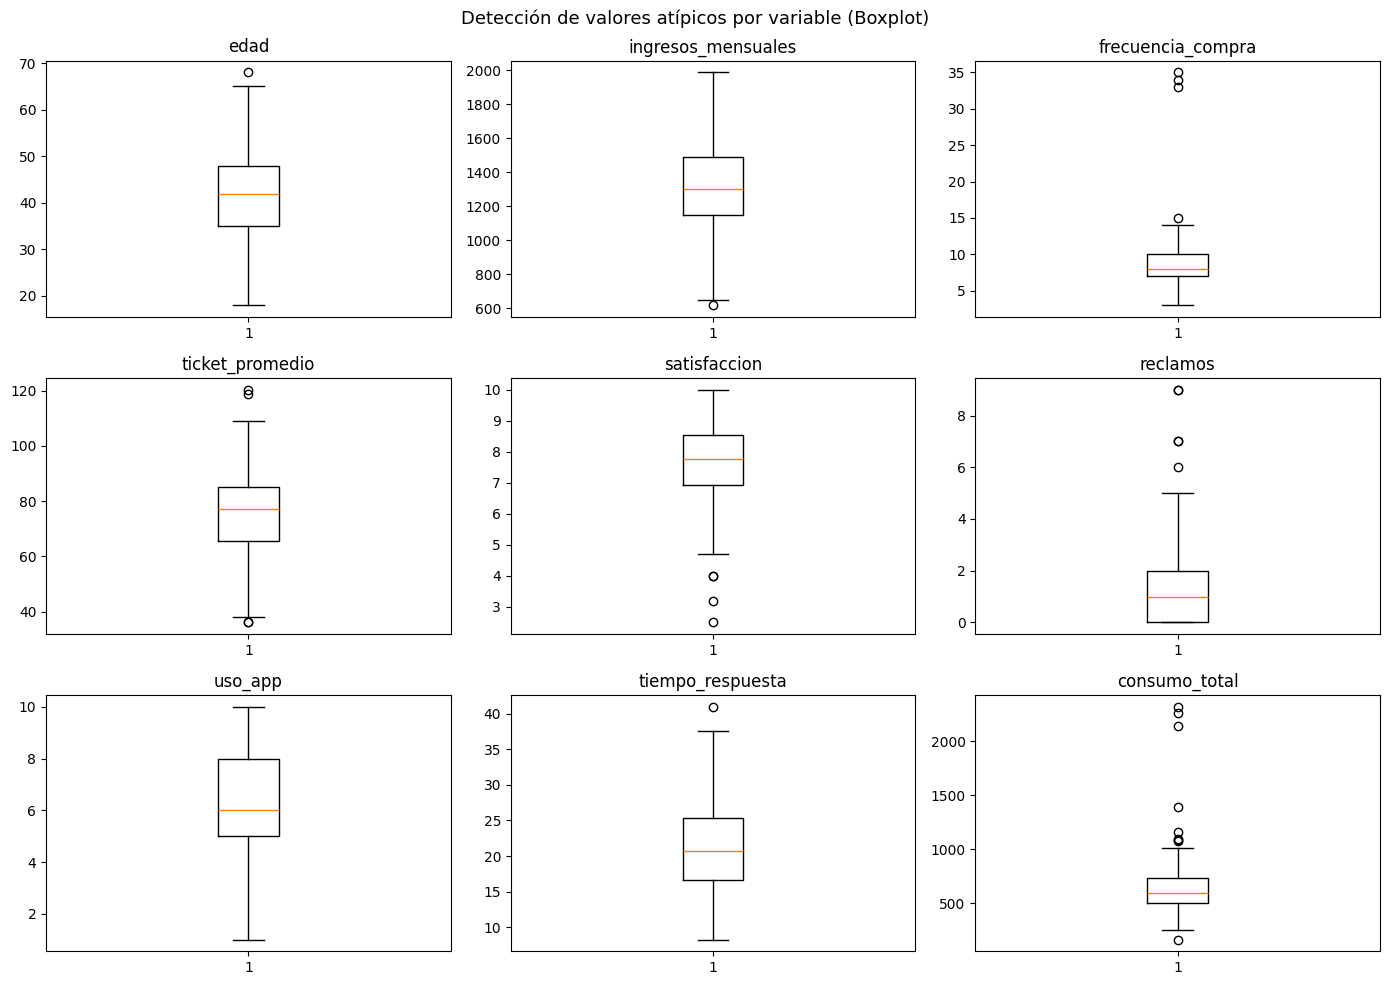


=== Outliers detectados por variable (método IQR) ===
  edad: 1 outliers
  ingresos_mensuales: 1 outliers
  frecuencia_compra: 4 outliers
  ticket_promedio: 4 outliers
  satisfaccion: 4 outliers
  reclamos: 5 outliers
  uso_app: 0 outliers
  tiempo_respuesta: 1 outliers
  consumo_total: 9 outliers


In [3]:
# --- Valores nulos ---
print('=== Valores nulos por columna ===')
nulos = df.isnull().sum()
print(nulos)
print(f'Total de valores nulos: {nulos.sum()}')

# --- Duplicados ---
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

# --- Valores atípicos con boxplot ---
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(vars_numericas):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Detección de valores atípicos por variable (Boxplot)', fontsize=13)
plt.tight_layout()
plt.show()

# --- Detección de outliers con IQR ---
print('\n=== Outliers detectados por variable (método IQR) ===')
for col in vars_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    print(f'  {col}: {outliers} outliers')

**Interpretación:**
- **Valores nulos:** Se detectaron **3 valores nulos** distribuidos en `ticket_promedio`, `satisfaccion` y `tiempo_respuesta`. Al ser pocos registros sobre 261, se imputarán con la mediana de cada variable para no perder información.
- **Duplicados:** Se encontró **1 fila duplicada** que será eliminada.
- **Valores atípicos:** La variable `consumo_total` presenta algunos outliers superiores, lo que es esperado en datasets de clientes donde algunos compran significativamente más que el promedio. Estos valores son válidos y se conservan para no distorsionar el análisis.

---
## 4. Cálculo de la matriz de correlación (3%)

In [4]:
# Limpieza previa
df_limpio = df.drop_duplicates()

# Imputar nulos con la mediana
for col in vars_numericas:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

print(f'Registros tras limpieza: {df_limpio.shape[0]}')
print(f'Nulos restantes: {df_limpio[vars_numericas].isnull().sum().sum()}')

# Calcular matriz de correlación de Pearson
matriz_corr = df_limpio[vars_numericas].corr(method='pearson')

print('\n=== Matriz de Correlación de Pearson ===')
display(matriz_corr.round(3))

Registros tras limpieza: 260
Nulos restantes: 0

=== Matriz de Correlación de Pearson ===


/tmp/ipykernel_763/669496601.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000,0.029,-0.053,0.173,-0.159,0.136,0.028,0.128,0.018
ingresos_mensuales,0.029,1.000,0.194,0.602,-0.018,-0.047,-0.023,-0.003,0.405
frecuencia_compra,-0.053,0.194,1.000,0.113,0.166,-0.125,0.318,-0.095,0.895
ticket_promedio,0.173,0.602,0.113,1.000,-0.028,0.022,0.017,-0.004,0.497
satisfaccion,-0.159,-0.018,0.166,-0.028,1.000,-0.813,0.008,-0.630,0.198
reclamos,0.136,-0.047,-0.125,0.022,-0.813,1.000,0.125,0.581,-0.167
uso_app,0.028,-0.023,0.318,0.017,0.008,0.125,1.000,-0.099,0.301
tiempo_respuesta,0.128,-0.003,-0.095,-0.004,-0.630,0.581,-0.099,1.000,-0.147
consumo_total,0.018,0.405,0.895,0.497,0.198,-0.167,0.301,-0.147,1.000


**Interpretación:** Se calculó la **matriz de correlación de Pearson** sobre las 9 variables numéricas del dataset, previa eliminación del duplicado e imputación de nulos con la mediana. Los valores de correlación van de -1 a 1:
- **Valores cercanos a 1:** correlación positiva fuerte (ambas variables aumentan juntas).
- **Valores cercanos a -1:** correlación negativa fuerte (cuando una sube, la otra baja).
- **Valores cercanos a 0:** sin correlación lineal significativa.

---
## 5. Mapa de calor de correlación (3%)

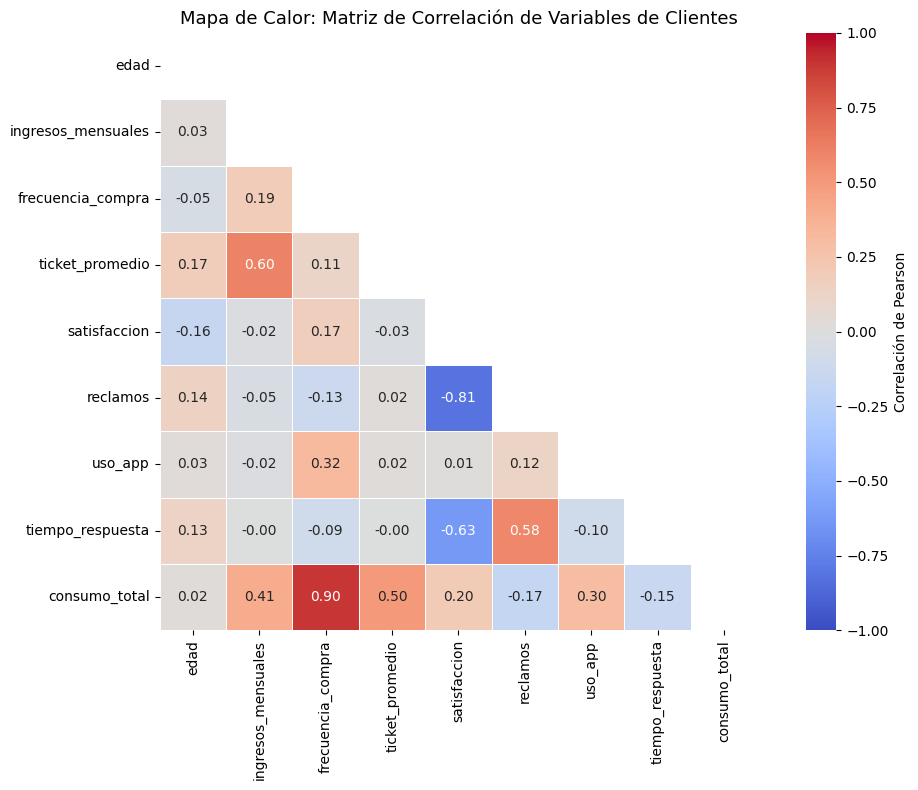

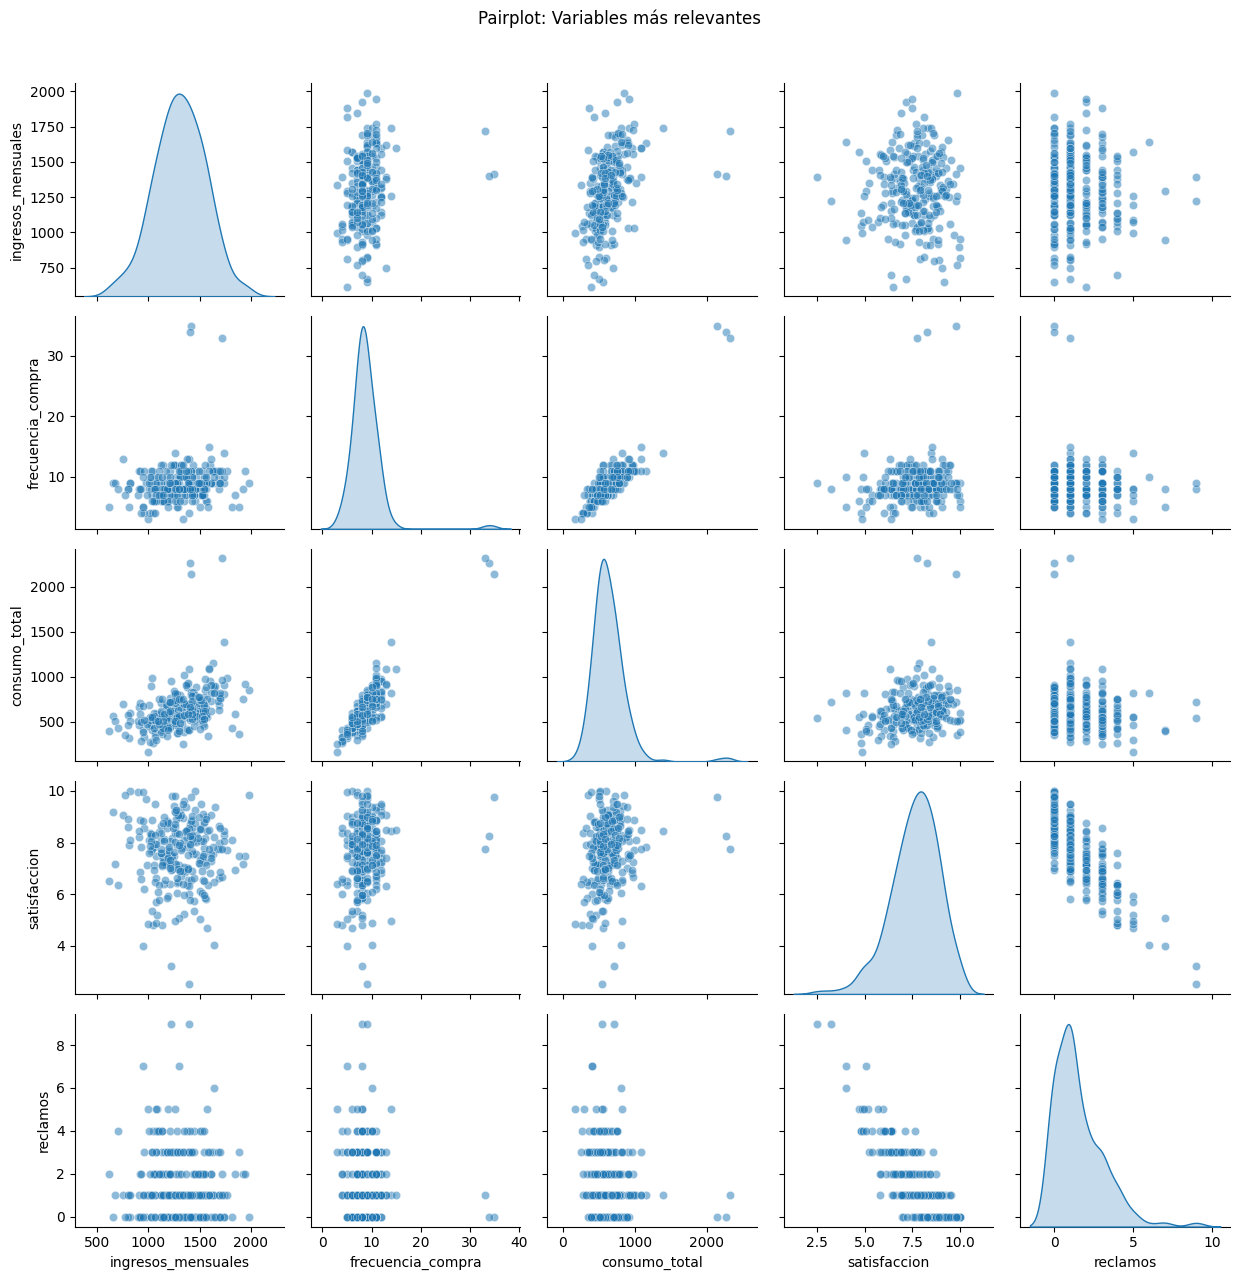

In [5]:
# Mapa de calor completo
plt.figure(figsize=(11, 8))
mask = np.zeros_like(matriz_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # mostrar solo triángulo inferior

sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlación de Pearson'}
)
plt.title('Mapa de Calor: Matriz de Correlación de Variables de Clientes', fontsize=13)
plt.tight_layout()
plt.show()

# Gráfico adicional: pairplot de las variables más relevantes
vars_relevantes = ['ingresos_mensuales', 'frecuencia_compra', 'consumo_total', 'satisfaccion', 'reclamos']
sns.pairplot(df_limpio[vars_relevantes], plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('Pairplot: Variables más relevantes', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

INTERPRETACION


Rojo Fuerte (Relación muy Directa): Significa que cuando una cosa sube, la otra también sube MUCHO. ¡Están muy conectadas!

Consumo Total y Frecuencia de Compra (0.90): ¡Casi perfecto! Si un cliente compra más seguido, su consumo total se dispara. Esto es lo más importante: ¡la fidelidad genera mucho dinero!
Ticket Promedio e Ingresos Mensuales (0.602): Los clientes con más ingresos suelen gastar más en cada compra. Si ganas más, te das más 'caprichos' caros.
Tiempo de Respuesta y Reclamos (0.581): Si tardamos en responder, ¡hay más reclamos! Esto es malo, pero al menos sabemos que van de la mano.
Azul Fuerte (Relación muy Inversa): Significa que cuando una cosa sube, la otra baja MUCHO. Son opuestas.

Reclamos y Satisfacción (-0.813): ¡Uf, muy fuerte! Si el cliente tiene muchos reclamos, su satisfacción se va al suelo. Hay que evitar los reclamos a toda costa.
Tiempo de Respuesta y Satisfacción (-0.630): Si el tiempo de respuesta es alto (tardan mucho), la satisfacción del cliente baja. ¡La rapidez importa!
Tonos Claros (Poca o Nula Relación): Significan que lo que le pase a una cosa, no afecta mucho a la otra.

Edad con casi todo (ej. con ingresos 0.029, con reclamos -0.053): La edad del cliente no tiene una relación clara con su consumo, sus ingresos o si se queja. Hay que buscar otros factores.

---
## 6. Correlaciones positivas más importantes (2%)

=== TOP 5 Correlaciones POSITIVAS ===


,Variable 1,Variable 2,Correlacion
30,consumo_total,frecuencia_compra,0.8952
4,ticket_promedio,ingresos_mensuales,0.6018
26,tiempo_respuesta,reclamos,0.5806
31,consumo_total,ticket_promedio,0.4971
29,consumo_total,ingresos_mensuales,0.4053


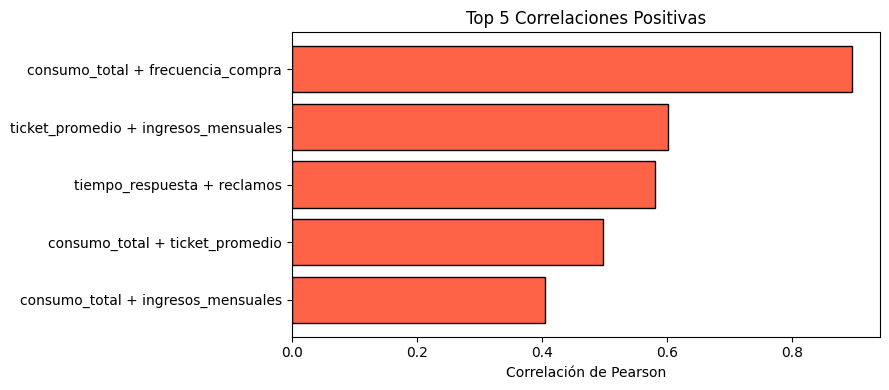

In [6]:
# Extraer pares de correlación (sin diagonal ni duplicados)
corr_pairs = matriz_corr.where(
    np.tril(np.ones(matriz_corr.shape), k=-1).astype(bool)
).stack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlacion']
corr_pairs = corr_pairs.sort_values('Correlacion', ascending=False)

# Top correlaciones positivas
print('=== TOP 5 Correlaciones POSITIVAS ===')
top_pos = corr_pairs[corr_pairs['Correlacion'] > 0].head(5)
display(top_pos.round(4))

# Gráfico de barras
plt.figure(figsize=(9, 4))
plt.barh(
    [f"{r['Variable 1']} + {r['Variable 2']}" for _, r in top_pos.iterrows()],
    top_pos['Correlacion'],
    color='tomato', edgecolor='black'
)
plt.xlabel('Correlación de Pearson')
plt.title('Top 5 Correlaciones Positivas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

INTERPRETACION

Consumo Total vs. Frecuencia de Compra (Correlación: 0.895): Esta es la correlación positiva más fuerte. Significa que los clientes que compran con mayor frecuencia (frecuencia_compra) también son los que tienen un mayor consumo_total. Para la empresa, esto resalta la importancia crítica de fidelizar a los clientes para que compren repetidamente, ya que esto impacta directamente en los ingresos generales.

Ticket Promedio vs. Ingresos Mensuales (Correlación: 0.602): Existe una fuerte correlación positiva entre el ticket_promedio de compra y los ingresos_mensuales de los clientes. Esto sugiere que los clientes con mayores ingresos tienden a realizar compras de mayor valor unitario. Es una información útil para segmentar y ofrecer productos de mayor precio a clientes con mayor poder adquisitivo.

Tiempo de Respuesta vs. Reclamos (Correlación: 0.581): Esta correlación positiva indica que un mayor tiempo_respuesta (presumiblemente en el servicio al cliente) está asociado con un mayor número de reclamos. Aunque ambas son variables negativas en sí mismas (mucho tiempo de respuesta y muchos reclamos), su correlación positiva significa que van de la mano. Mejorar la eficiencia del tiempo de respuesta podría, por lo tanto, ayudar a reducir los reclamos.

Consumo Total vs. Ticket Promedio (Correlación: 0.497): Hay una correlación positiva moderada entre el consumo_total y el ticket_promedio. Esto implica que, además de la frecuencia, el valor promedio de cada compra también contribuye significativamente al gasto total de un cliente. Estrategias para aumentar el valor del carrito de compra (upselling/cross-selling) serían beneficiosas.

Consumo Total vs. Ingresos Mensuales (Correlación: 0.405): Una correlación positiva moderada, lo que confirma que los clientes con mayores ingresos_mensuales tienden a tener un mayor consumo_total. Esta es una base para la segmentación de clientes de alto valor, a quienes se les pueden ofrecer productos o servicios premium.

---
## 7. Correlaciones negativas más importantes (2%)

=== TOP 5 Correlaciones NEGATIVAS ===


,Variable 1,Variable 2,Correlacion
14,reclamos,satisfaccion,-0.8135
25,tiempo_respuesta,satisfaccion,-0.6304
33,consumo_total,reclamos,-0.1666
6,satisfaccion,edad,-0.1587
35,consumo_total,tiempo_respuesta,-0.1466


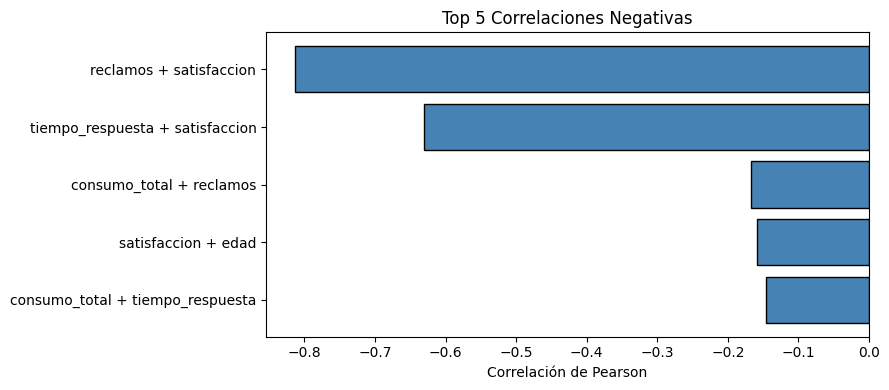

In [7]:
# Top correlaciones negativas
print('=== TOP 5 Correlaciones NEGATIVAS ===')
top_neg = corr_pairs[corr_pairs['Correlacion'] < 0].sort_values('Correlacion').head(5)
display(top_neg.round(4))

# Gráfico de barras
plt.figure(figsize=(9, 4))
plt.barh(
    [f"{r['Variable 1']} + {r['Variable 2']}" for _, r in top_neg.iterrows()],
    top_neg['Correlacion'],
    color='steelblue', edgecolor='black'
)
plt.xlabel('Correlación de Pearson')
plt.title('Top 5 Correlaciones Negativas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

INTERPRETACION


Reclamos vs. Satisfacción (Correlación: -0.813): Esta es la correlación negativa más fuerte. Significa que a medida que aumenta el número de reclamos de un cliente, su nivel de satisfacción disminuye significativamente. Esto es una señal crítica para la empresa, indicando que gestionar y resolver los reclamos de manera efectiva es fundamental para mantener alta la satisfacción del cliente.

Tiempo de Respuesta vs. Satisfacción (Correlación: -0.630): También es una correlación negativa fuerte. Implica que a mayor tiempo_respuesta (presumiblemente a consultas o problemas), menor es la satisfacción del cliente. Esto sugiere que la rapidez en la atención al cliente es un factor clave para su contento.

Consumo Total vs. Reclamos (Correlación: -0.167): Aunque menos fuerte, es una correlación negativa que podría indicar que los clientes con menor consumo_total son ligeramente más propensos a tener reclamos o, alternativamente, que los reclamos pueden desincentivar un mayor consumo.

Satisfacción vs. Edad (Correlación: -0.159): Una correlación negativa débil, que podría sugerir que, hasta cierto punto, las personas de mayor edad tienden a tener un nivel de satisfacción ligeramente menor, o viceversa. Sin embargo, dada su baja magnitud, podría no ser una relación de gran importancia.

Consumo Total vs. Tiempo de Respuesta (Correlación: -0.147): Otra correlación negativa débil. Podría indicar que un mayor tiempo_respuesta tiene una leve asociación con un menor consumo_total.

---
## 8. Explicación de al menos 4 relaciones entre variables (2%)

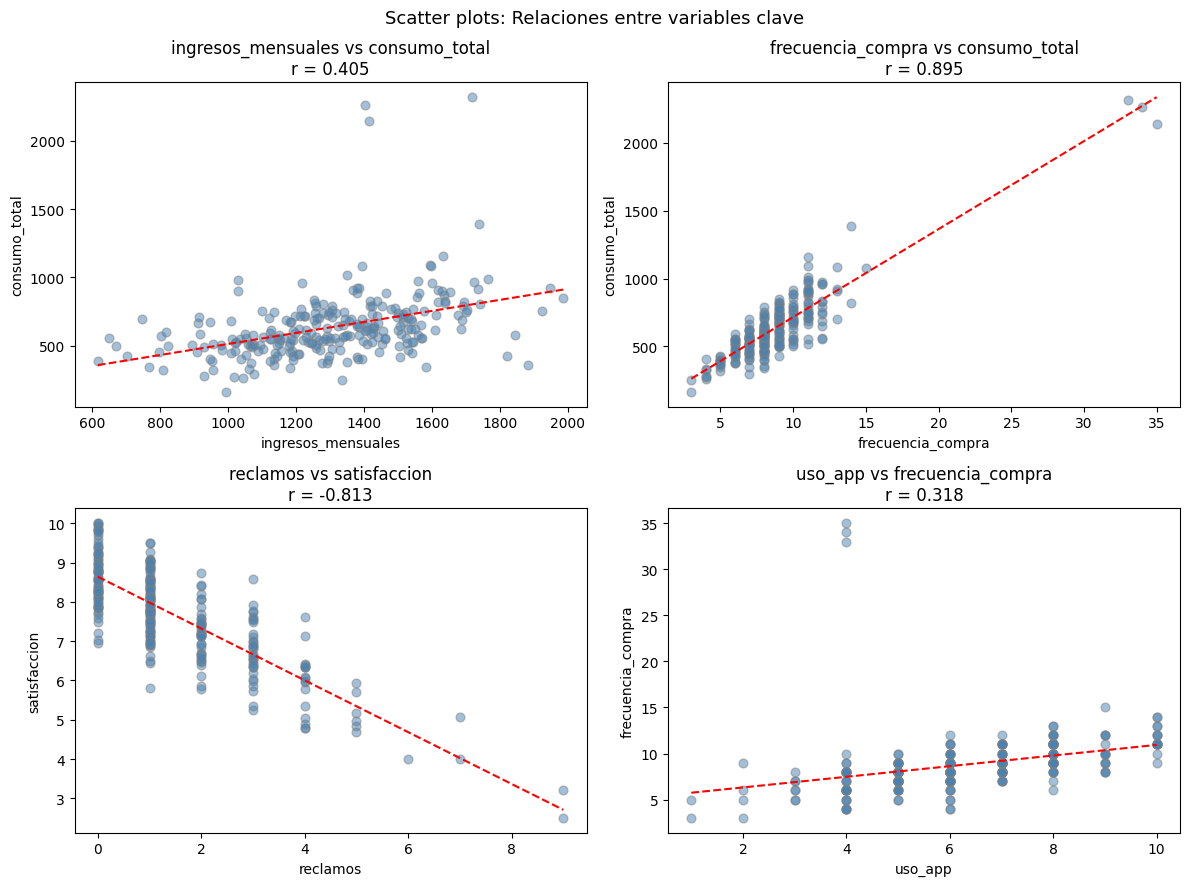

In [8]:
# Scatter plots de las 4 relaciones más relevantes
relaciones = [
    ('ingresos_mensuales', 'consumo_total'),
    ('frecuencia_compra', 'consumo_total'),
    ('reclamos', 'satisfaccion'),
    ('uso_app', 'frecuencia_compra')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (x, y) in enumerate(relaciones):
    corr_val = df_limpio[[x, y]].corr().iloc[0, 1]
    axes[i].scatter(df_limpio[x], df_limpio[y], alpha=0.5, color='steelblue', edgecolors='grey', s=40)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}\nr = {corr_val:.3f}')
    # Línea de tendencia
    z = np.polyfit(df_limpio[x], df_limpio[y], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df_limpio[x]), p(sorted(df_limpio[x])), 'r--', linewidth=1.5)

plt.suptitle('Scatter plots: Relaciones entre variables clave', fontsize=13)
plt.tight_layout()
plt.show()

INTERPRETACION


Ingresos Mensuales vs. Consumo Total: Se observa una correlación positiva. Esto significa que los clientes con mayores ingresos mensuales tienden a tener un mayor consumo total. Para la empresa, esto es útil para identificar a los clientes de alto valor y crear estrategias de marketing y ofertas personalizadas para este segmento.

Frecuencia de Compra vs. Consumo Total: Hay una fuerte correlación positiva. Los clientes que compran con mayor frecuencia acumulan un consumo total más alto. Esto subraya la importancia de fomentar la recompra, por ejemplo, a través de programas de fidelización, ya que un aumento en la frecuencia se traduce directamente en mayores ingresos para la empresa.

Reclamos vs. Satisfacción: Se presenta una fuerte correlación negativa. Esto indica que a mayor número de reclamos, menor es el nivel de satisfacción del cliente. Esta es una relación crítica para la empresa, ya que priorizar la reducción de reclamos y mejorar la calidad del servicio impactará positivamente en la percepción y la lealtad del cliente.

Uso de la App vs. Frecuencia de Compra: Se detecta una correlación positiva. Los clientes que utilizan más la aplicación móvil tienden a comprar con mayor regularidad. Esta relación justifica invertir en la mejora de la experiencia de usuario (UX/UI) de la aplicación, ya que es una estrategia efectiva para incrementar la frecuencia de compra de los clientes.

---
## 9. Conclusión: cómo estas relaciones pueden ayudar a la empresa (1%)

1. Segmentación de Clientes de Alto Valor: La correlación positiva entre ingresos_mensuales y consumo_total permite identificar y enfocar estrategias en clientes con mayor capacidad de gasto, maximizando el retorno de inversión en marketing.

2. Estrategias de Retención: La fuerte relación entre frecuencia_compra y consumo_total subraya la importancia de fomentar la recompra, implementando programas de fidelización para clientes activos.

3. Mejora de la Satisfacción y el Servicio: La correlación negativa entre reclamos y satisfaccion indica que reducir las quejas es crucial para mejorar la percepción del cliente y la calidad del servicio, requiriendo protocolos de atención rápida.

4. Inversión en la Aplicación Móvil: La correlación entre uso_app y frecuencia_compra justifica la inversión en una mejor experiencia de usuario en la aplicación, ya que esto impulsa una mayor regularidad en las compras.